In [2]:
library(tidyverse)
library(glue)
library(patchwork)
library(readr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 15.7.4

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/envs/r-notebook/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Europe/Brussels
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2 glue_1.8.0      lubridate_1.9.4 forcats_1.0.0  
 [5] stringr_1.5.2   dplyr_1.1.4     purrr_1.1.0     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.3.0    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     compiler_4.3.3     crayon_1.5.3      
 [5] tidyselect_1.2.1   IRdisplay_1.1      systemfonts_1.2.3  scales_1.4.0      
 [9] textshaping_1.0.3  uuid_1.2-1         fastmap_1.2.0      IRkernel_1.3.2    
[13] R6_2.6.1           generics_0.1.4     pillar_1.11.

In [4]:
# Define Ct value categories
Ct_categories <- data.frame(
    upper_limit = c(19, 25, 30, 35, Inf),
    category = c("Super low", "Low", "Mid", "High", "Super high")
)

ct_values <- read_tsv("./data-preparation/sample-metadata/ct-values.tsv")%>%
    rename(diag_ct = `Diagnostic_PCR_LASV_GPC-Gene_Ct`,
        extraction_ct = `KUL_EXT_PCR1_LASV-GPC-Gene_Ct`
    )

Rows: 142 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): sample
dbl (2): Diagnostic_PCR_LASV_GPC-Gene_Ct, KUL_EXT_PCR1_LASV-GPC-Gene_Ct

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
# Run mmseqs for every reference against the complete references
system("mkdir -p data-preparation/mmseqs-results")
system("mkdir -p data-preparation/tmp")
# Uncomment to run mmseqs2 searches
consensus_files <- list.files("data-preparation/consensus", pattern = "\\.fasta$", full.names = TRUE)

colnames_mmseqs <- c("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,qlen,tstart,tend,tlen,evalue,bits")

# walk(consensus_files, function(fasta) {
#   basename <- str_remove(basename(fasta), "\\.fasta$")
#   potential_references <- "data-preparation/ncbi-virus-fasta/sequences_20251024_LASV.fasta"
#   message(glue("Running mmseqs2 for {basename}\n"))
#   system(glue("conda run -n mmseqs2-env mmseqs easy-search --max-seq-id 1.0 --search-type 3 --format-output {colnames_mmseqs} {fasta} {potential_references} data-preparation/mmseqs-results/{basename}_mmseqs.out.m8 data-preparation/tmp"))
# })

In [6]:
# Combine mmseqs results
mmseqs <- list.files("data-preparation/mmseqs-results/") %>%
    map_dfr(~ {
        df <- read.table(paste0("data-preparation/mmseqs-results/", .), sep="\t", col.names = str_split(colnames_mmseqs, ",")[[1]])
        df$segment <- .
        df
    }) %>%
    mutate(segment = gsub(".*_(S|L|M)_.*", "\\1", segment))%>%
    mutate(query = gsub("_[L|S]","", query ))%>%
    filter(fident >=0.64) %>%
    filter((tlen >=6700 & tlen <=7500) | (tlen >=2900 & tlen <=3600))%>%
    mutate(fident_window = cut(as.numeric(fident), breaks = seq(0.64, 1, by = 0.02), include.lowest = TRUE))

set.seed(42)
selected_references <- mmseqs %>%
    group_by(query, segment, fident_window) %>%
    slice_max(order_by = bits, n=1, with_ties = FALSE) %>%
    ungroup()%>%
    arrange(query, segment, desc(fident))

mmseqs <- merge(mmseqs, selected_references%>%mutate(is_selected = TRUE)%>%select(query,target,bits, is_selected), by = c("query","target","bits"), all.x=TRUE)%>%
  mutate(is_selected = ifelse(is.na(is_selected), FALSE, is_selected))

Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with
`binwidth`.


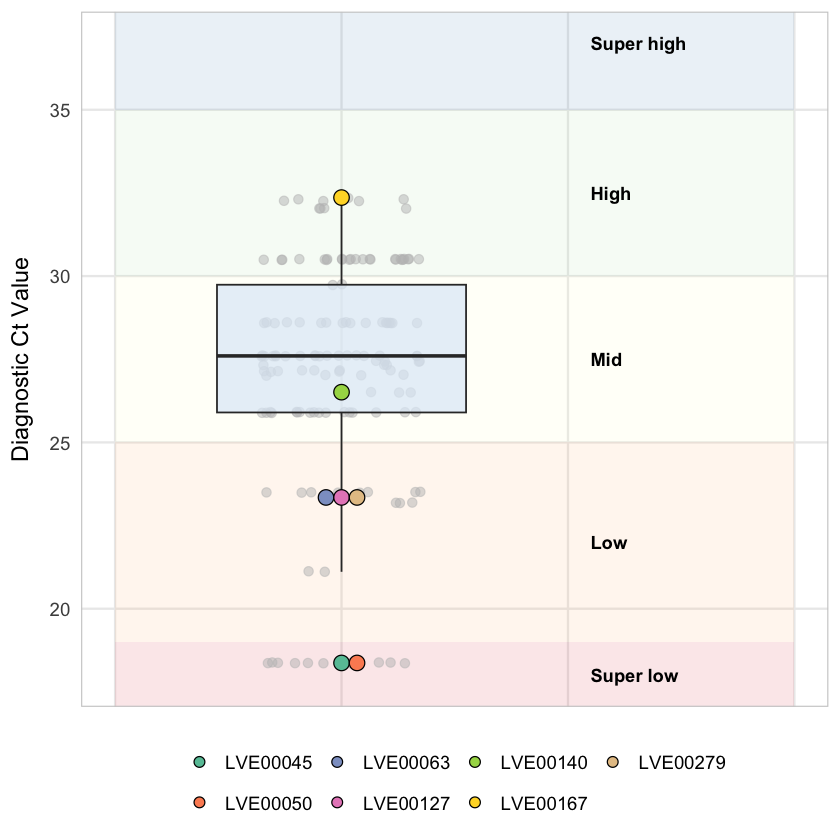

In [7]:
samples <- mmseqs%>%filter(query!= "LVE00223")%>% pull(query)%>%unique()

# Define common theme
theme_style <- theme_minimal(base_size = 14) +
    theme(
        axis.title.x = element_text(margin = margin(t = 10)),
        axis.text.x = element_blank(),
        axis.title.y = element_text(margin = margin(r = 10)),
        panel.grid.minor = element_blank(),
        panel.border = element_rect(colour = "grey80", fill = NA),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom",
        legend.box = "horizontal",
        legend.title = element_blank()
    )

p <- ggplot(ct_values, aes(x= 1, y = diag_ct)) +
    # Add zones
    annotate("rect", xmin = 0.5, xmax = 2, ymin = -Inf, ymax = 19, fill = "#D7191C", alpha = 0.1) +
    annotate("rect", xmin = 0.5, xmax = 2, ymin = 19, ymax = 25, fill = "#FDAE61", alpha = 0.1) +
    annotate("rect", xmin = 0.5, xmax = 2, ymin = 25, ymax = 30, fill = "#FFFFBF", alpha = 0.1) +
    annotate("rect", xmin = 0.5, xmax = 2, ymin = 30, ymax = 35, fill = "#ABDDA4", alpha = 0.1) +
    annotate("rect", xmin = 0.5, xmax = 2, ymin = 35, ymax = Inf, fill = "#2B83BA", alpha = 0.1) +

    # Add text labels
    annotate("text", x = 1.55, y = 18, label = "Super low", fontface = "bold", color = "black", hjust = 0) +
    annotate("text", x = 1.55, y = 22, label = "Low", fontface = "bold", color = "black", hjust = 0) +
    annotate("text", x = 1.55, y = 27.5, label = "Mid", fontface = "bold", color = "black", hjust = 0) +
    annotate("text", x = 1.55, y = 32.5, label = "High", fontface = "bold", color = "black", hjust = 0) +
    annotate("text", x = 1.55, y = 37, label = "Super high", fontface = "bold", color = "black", hjust = 0) +

    geom_jitter(
        data= ct_values%>%filter(!(sample %in%samples)),
        color = "grey",
        alpha = 0.5,
        width = 0.18, size = 2.3
    ) +
    geom_boxplot(
        width = 0.55, fill = "#deebf7", alpha = 0.7, outlier.shape = NA
    )+
    geom_dotplot(
        data = ct_values %>%filter((sample %in%samples)),
        aes(fill = sample),
        binaxis = "y",
        stackdir = "centerwhole",
        method="dotdensity",
        stackgroups = T,
        binpositions="all",
        dotsize = 1
    ) +
    scale_fill_brewer(palette = "Set2") +
    theme_style +
    labs(x = NULL, y = "Diagnostic Ct Value")

p
ggsave("./images/ct-values.png", p, width = 6, height = 7, dpi = 300)
ggsave("./../../../Fig/supplfig2.png", p, width = 6, height =7, dpi = 300)

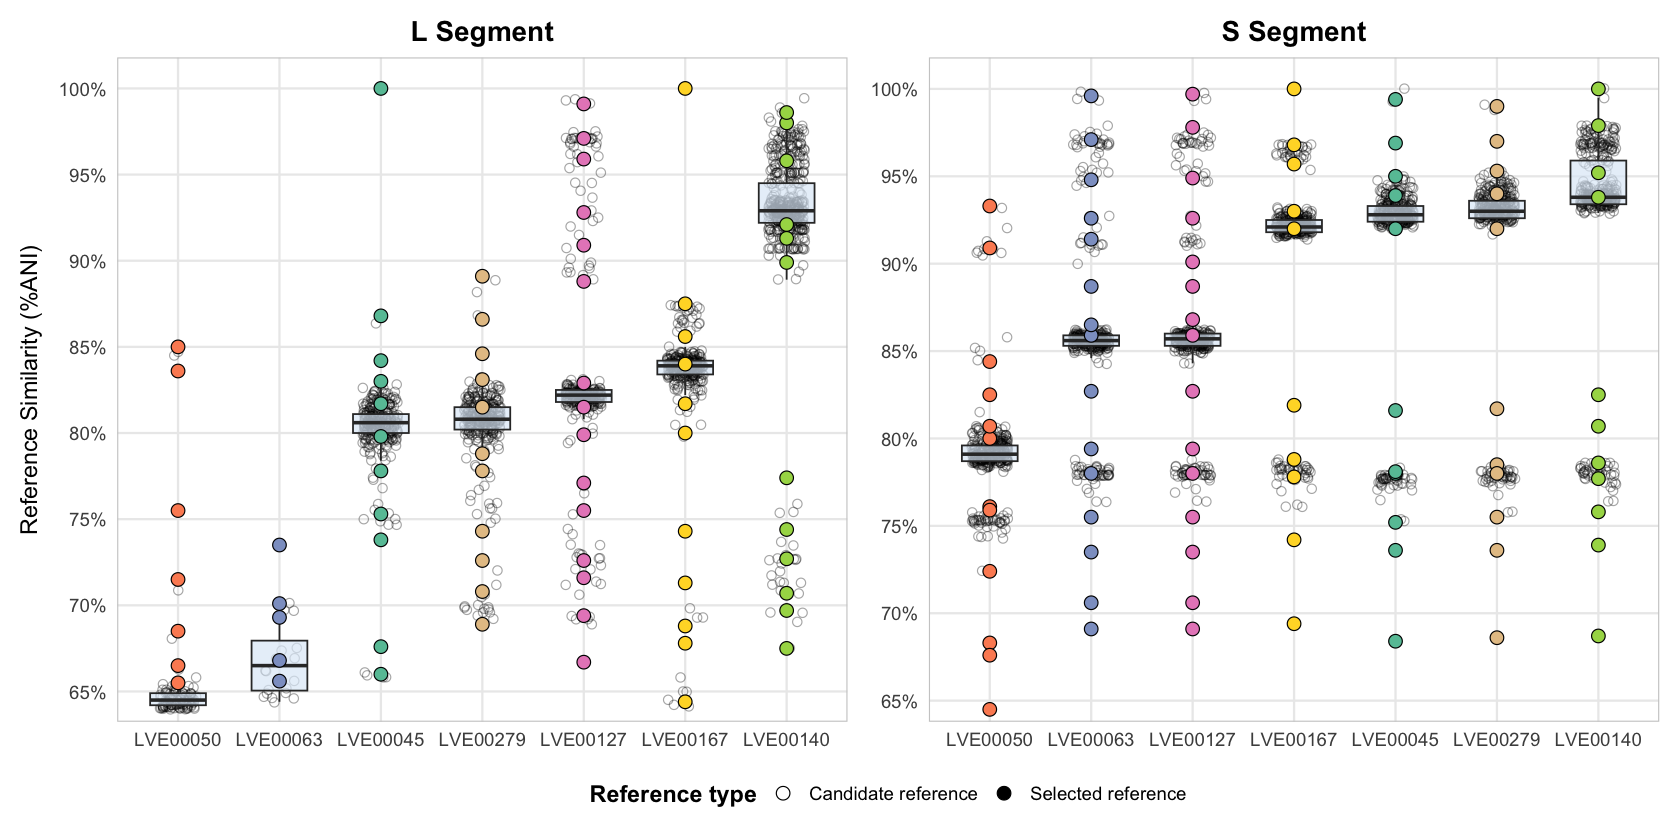

In [8]:
options(repr.plot.width = 14, repr.plot.height = 7)

mmseqs_plot <- mmseqs %>%
    filter(query != "LVE00223") %>%
    mutate(
        selection = if_else(is_selected, "Selected reference", "Candidate reference"),
        selection = factor(selection, levels = c("Selected reference", "Candidate reference")),
        segment = recode(segment, "L" = "L segment", "S" = "S segment", "M" = "M segment")
    ) %>%
    tidyr::drop_na(fident)

# Define common theme
theme_style <- theme_minimal(base_size = 14) +
    theme(
        # axis.text.x = element_blank(),
        axis.title.x = element_text(margin = margin(t = 10)),
        axis.title.y = element_text(margin = margin(r = 10)),
        panel.grid.minor = element_blank(),
        panel.border = element_rect(colour = "grey80", fill = NA),
        plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "bottom",
        legend.box = "horizontal",
        legend.title = element_text(face = "bold")
    )

# Plot L Segment
p_L <- ggplot(filter(mmseqs_plot, segment == "L segment"),
              aes(x = reorder(query, fident, median, na.rm = TRUE), y = fident)) +
    geom_jitter(
        data = filter(mmseqs_plot, segment == "L segment", !is_selected),
        aes(shape = selection, alpha = selection),
        fill = "grey",
        width = 0.18, size = 2.3
    ) +
    geom_boxplot(
        aes(group = query),
        width = 0.55, fill = "#deebf7", alpha = 0.7, outlier.shape = NA
    ) +
    geom_point(
        data = filter(mmseqs_plot, segment == "L segment", is_selected),
        aes(fill = query, shape = selection, alpha = selection),
        size = 3.5
    ) +
    scale_fill_brewer(palette = "Set2") +
    scale_shape_manual(
        values = c("Selected reference" = 21, "Candidate reference" = 1),
        guide = guide_legend(
            title = "Reference type",
            override.aes = list(
                fill ="black",
                color = "black",
                alpha = 1,
                size = 3.5
            )
        )
    ) +
    scale_alpha_manual(values = c("Selected reference" = 1, "Candidate reference" = 0.35), guide = "none") +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.05))
    ) +
    labs(x = NULL, y = "Reference Similarity (%ANI)", title = "L Segment") +
    theme_style +
    guides(fill = "none")

# Plot S Segment
p_S <- ggplot(filter(mmseqs_plot, segment == "S segment"),
              aes(x = reorder(query, fident, median, na.rm = TRUE), y = fident)) +
    geom_jitter(
        data = filter(mmseqs_plot, segment == "S segment", !is_selected),
        aes(shape = selection, alpha = selection),
        fill = "grey",
        width = 0.18, size = 2.3
    ) +
    geom_boxplot(
        aes(group = query),
        width = 0.55, fill = "#deebf7", alpha = 0.7, outlier.shape = NA
    ) +
    geom_point(
        data = filter(mmseqs_plot, segment == "S segment", is_selected),
        aes(fill = query, shape = selection, alpha = selection),
        size = 3.5
    ) +
    scale_fill_brewer(palette = "Set2") +
    scale_shape_manual(
        values = c("Selected reference" = 21, "Candidate reference" = 1),
        guide = guide_legend(
            title = "Reference type",
            override.aes = list(
                fill = "black",
                color = "black",
                alpha = 1,
                size = 3.5
            )
        )
    ) +
    scale_alpha_manual(values = c("Selected reference" = 1, "Candidate reference" = 0.35), guide = "none") +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.05))
    ) +
    labs(x = NULL, y = NULL, title = "S Segment") +
    theme_style +
    guides(fill = "none")

# Combine
p <- (p_L | p_S) +
        plot_layout(guides = "collect") +
        plot_annotation(
            theme = theme(
                plot.title = element_text(hjust = 0.5, face = "bold"),
                plot.subtitle = element_text(hjust = 0.5)
            )
        ) & theme(legend.position = "bottom")

p

# Save plot
ggsave("images/supplfig-3_reference_selection.png", p, width = 14, height = 7, dpi = 300)
ggsave("../../../Fig/supplfig3.png", p, width = 14, height = 7, dpi = 300)

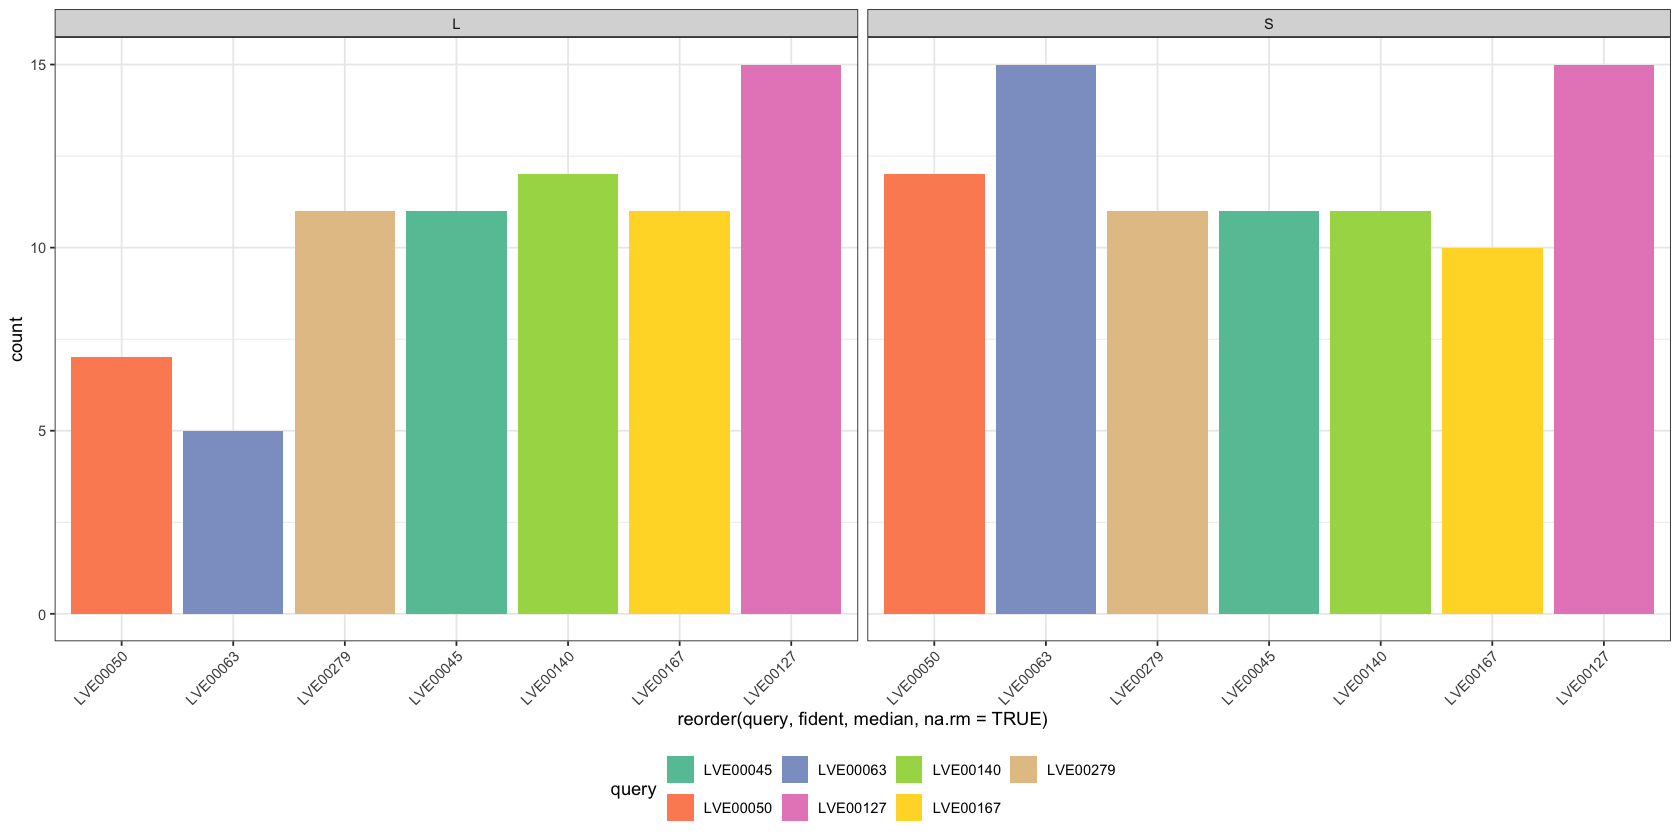

In [12]:
# Checking how many we have for every query
ggplot(selected_references %>% filter(query != "LVE00223"), aes(x = reorder(query, fident, median, na.rm = TRUE), fill = query)) +
  facet_wrap(~segment) +
  geom_bar() +
  theme_bw() +
  scale_fill_brewer(palette = "Set2") +
  theme(legend.position = "bottom") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The coverage on L for LVE00063 is just very bad.
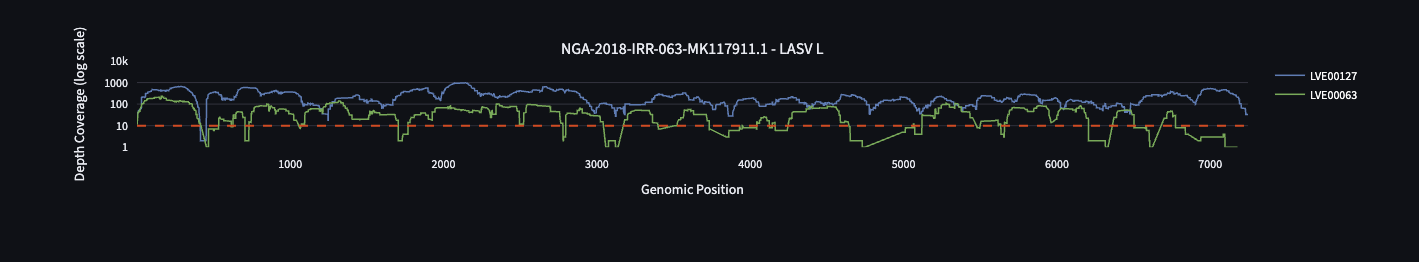


Not going to worry too much about it, I'm just going to start by selecting one sample (LVE00050) and one reference per window of identity.


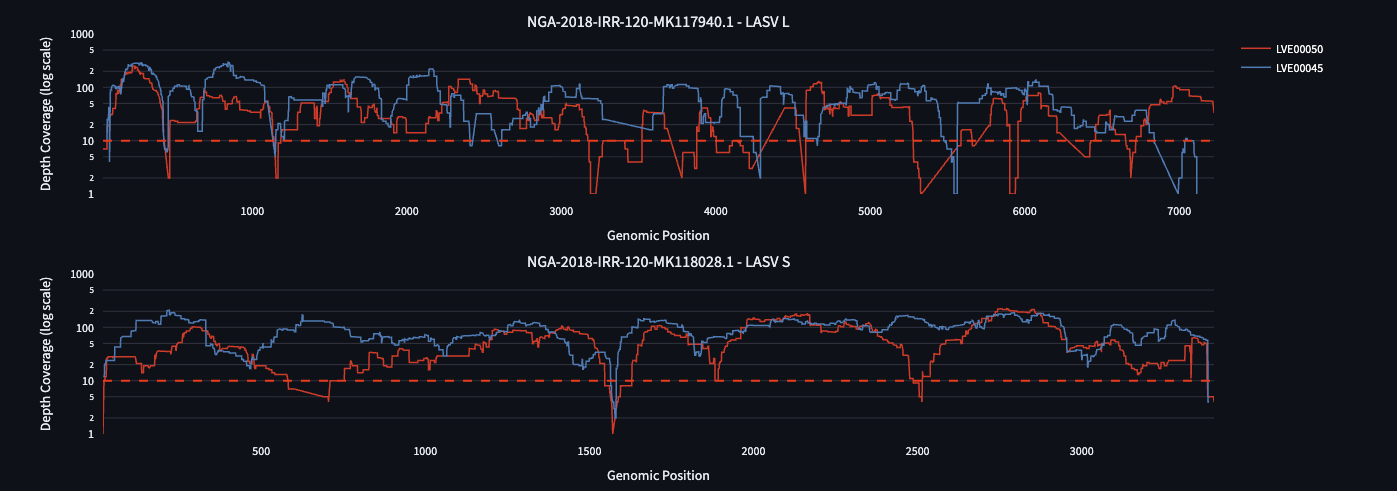


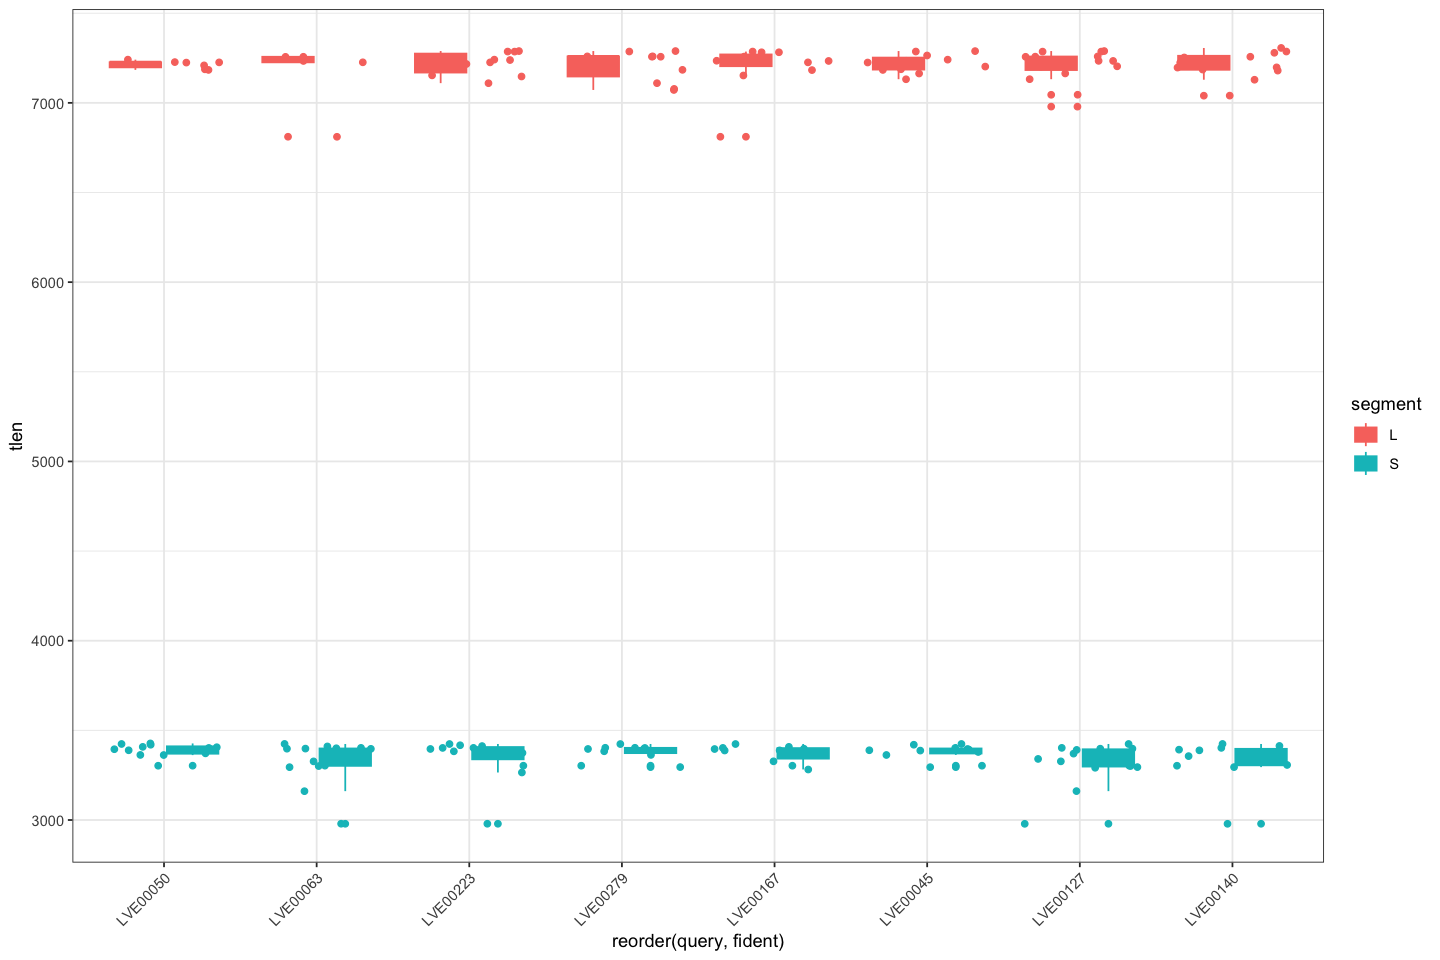

In [6]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = tlen, x = reorder(query, fident), fill = segment, color=segment)) +
  geom_boxplot() +
  geom_jitter() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [7]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

system("mkdir -p data-preparation/selected-references")

write_tsv(selected_references, "data-preparation/selected-references/selected_references.tsv")

out_dir <- "data-preparation/selected-references"

collapse <- selected_references%>%
    group_by(query, fident_window)%>%
    summarise(
      targets_regex = paste(target,collapse = " " ),
      segment = paste(segment, collapse =" ")
    )%>%
    ungroup()

`summarise()` has grouped output by 'query'. You can override using the
`.groups` argument.


In [109]:
head(collapse)

query,fident_window,targets_regex,segment
<chr>,<fct>,<chr>,<chr>
LVE00045,"[0.64,0.66]",MT199231.1,L
LVE00045,"(0.66,0.68]",MT199235.1,L
LVE00045,"(0.68,0.7]",OR041677.1,S
LVE00045,"(0.72,0.74]",PQ541162.1 OR041684.1,L S
LVE00045,"(0.74,0.76]",MK117836.1 OQ919510.1,L S
LVE00045,"(0.76,0.78]",MH053566.1 AY628205.1,L S


In [ ]:
system("mkdir -p data-preparation/selected-references")

apply(collapse, 1, function(x) {
    sample <- x[1]
    fident_window <- x[2]
    targets_regex <- x[3]
    fident_digits <- fident_window_to_digits(fident_window)
    outname <- gsub(" ", "-", targets_regex)
    regex <- gsub(" ",")|(", targets_regex)
    out_file <- glue("{out_dir}/{fident_digits}_{outname}.fasta")
    command <- glue("cat data-preparation/ncbi-virus-fasta/sequences_*_LASV.fasta | seqkit grep -r -p '({regex})' > {out_file}")
    system(command)
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [111]:
unique(collapse$query)

[1] "LVE00045" "LVE00050" "LVE00063" "LVE00127" "LVE00140" "LVE00167" "LVE00223"
[8] "LVE00279"

In [112]:
RVDB <- data.frame(
        sample = unique(collapse$query),
        sequence = rep("/lustre1/project/stg_00132/databases/RVDB/U-RVDBv29.0.fasta", length(unique(collapse$query))))%>%
    mutate(
        id= glue("{sample}-RVDB")
    )

collapse%>%
    mutate(
        id= glue("{query}-{fident_window_to_digits(fident_window)}"),
        sample = query,
        sequence = glue("{out_dir}/{fident_window_to_digits(fident_window)}_{gsub(' ', '-', targets_regex)}.fasta")
    )%>%
    select(id, sample, sequence, segment)%>%
    bind_rows(., RVDB)%>%
    arrange(sample)%>%
    write_csv( "reference_pools.csv")